# Introductory Figure

In [9]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
from scipy.ndimage import gaussian_filter1d
from math import comb
from tools import load
from PIL import Image
import subprocess, tempfile, os
import sklearn.metrics

rng = np.random.default_rng(42)
cm = ListedColormap(plt.rcParams['axes.prop_cycle'].by_key()['color'])


def backward_diff_array(y, h, n):
    """n-th backward finite difference (zero-padded to preserve length)."""
    coeffs = np.array([(-1)**k * comb(n, k) for k in range(n + 1)])
    raw = np.convolve(y, coeffs, mode='valid') / h**n
    return np.concatenate([np.zeros(n), raw])


def expand_with_derivatives(data, h, max_order):
    """Append backward differences of orders 1..max_order."""
    if max_order == 0:
        return data.copy()
    derivs = []
    for order in range(1, max_order + 1):
        d = np.apply_along_axis(
            lambda col: backward_diff_array(col, h, order), axis=0, arr=data)
        derivs.append(d)
    return np.hstack([data] + derivs)


def find_blocks(labels, max_len=20, ignore=0):
    labels = np.asarray(labels)
    n = len(labels)
    if n == 0:
        return []
    blocks, start, prev = [], 0, labels[0]
    for i in range(1, n + 1):
        cur = labels[i] if i < n else None
        if cur != prev:
            if prev != ignore:
                s = start
                while s < i:
                    e = min(s + max_len, i)
                    blocks.append((s, e, int(prev)))
                    s = e
            start, prev = i, cur
    return blocks


def block_edges_from_indices(x, s, e):
    L = x[0] if s <= 0 else 0.5 * (x[s-1] + x[s])
    R = x[-1] if e >= len(x) else 0.5 * (x[e-1] + x[e])
    return L, R


# --- Load and expand data ---
filename = '1_600_20'
sensor_data, sequence, times_sec, sequence_sec = load(filename, reduced=True)
h = np.median(np.diff(times_sec))

# Expand with d1 + d2 + d3
sensor_data = expand_with_derivatives(sensor_data, h, max_order=3)
print(f'Expanded sensor data shape: {sensor_data.shape}')

# --- Parameters ---
n_hd = 10000
n_out = 3
d = 0.05
k = int(d * n_hd)       # k = 500
p = 0.005
p_w_hd = 0.75
n_train = 450

x_dense = sensor_data
n_dense = x_dense.shape[1]

# Build per-sample labels
labels = np.zeros_like(times_sec)
for i, t in enumerate(sequence_sec[:n_train]):
    try:
        flag = (times_sec > sequence_sec[i]) & (times_sec < sequence_sec[i+1])
    except IndexError:
        flag = (times_sec > sequence_sec[i])
    labels[flag] = int(sequence[i][1])

idx_last_flag = np.where(labels != 0)[0][-1]

# Random projection + top-k
W_hd = np.random.binomial(n=1, p=p_w_hd, size=(n_hd, n_dense))
x_hd = x_dense @ W_hd.T
ranks = np.argsort(np.argsort(-x_hd, axis=1), axis=1)
z_hd = np.where(ranks < k, 1., 0.)

# Online learning
W_out = np.zeros((n_out, n_hd))
z_out_train = np.zeros((z_hd.shape[0], n_out))
for i, row in enumerate(z_hd[:idx_last_flag]):
    if labels[i] != 0:
        active_idx = np.flatnonzero(row)
        to_flip = active_idx[rng.random(active_idx.size) < p]
        W_out[int(labels[i])-1, to_flip] = 1./k
    out = row @ W_out.T
    z_out_train[i] = out

# Full readout
z_out_acc = np.zeros((z_hd.shape[0], n_out))
for i, row in enumerate(z_hd):
    out = row @ W_out.T
    z_out_acc[i] = out

# Accuracy
z_pred = np.zeros_like(sequence_sec)
z_true = np.zeros_like(sequence_sec)
for i, t in enumerate(sequence_sec):
    try:
        flag = (times_sec > sequence_sec[i]) & (times_sec < sequence_sec[i+1])
    except IndexError:
        flag = (times_sec > sequence_sec[i])
    z_pred[i] = np.argsort(np.sum(z_out_acc[flag], axis=0))[-1] + 1
    z_true[i] = sequence[i][1]

train_acc = sklearn.metrics.accuracy_score(z_true[:n_train], z_pred[:n_train])
test_acc = sklearn.metrics.accuracy_score(z_true[n_train:], z_pred[n_train:])
print(f'k: {k}, p: {p}, p_hd: {p_w_hd}')
print(f'Train accuracy: {train_acc:.4f}, Test accuracy: {test_acc:.4f}')

# Combined z_out: train during training, acc afterwards
z_out = np.empty((z_hd.shape[0], n_out))
z_out[:idx_last_flag] = z_out_train[:idx_last_flag]
z_out[idx_last_flag:] = z_out_acc[idx_last_flag:]

Expanded sensor data shape: (11691, 32)
k: 500, p: 0.005, p_hd: 0.75
Train accuracy: 0.9956, Test accuracy: 1.0000


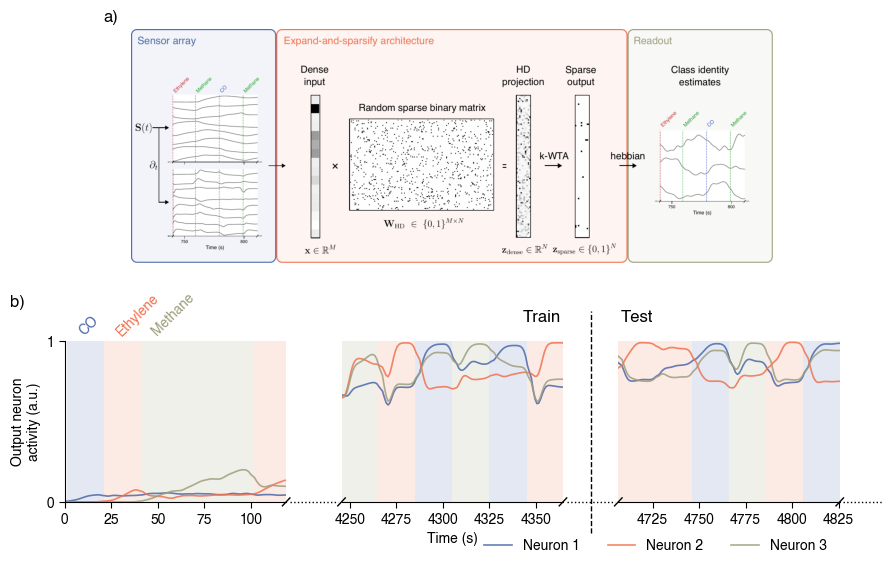

In [10]:
# --- Convert model_fig.pdf to image ---
pdf_path = 'figs/model_fig.pdf'
with tempfile.TemporaryDirectory() as tmpdir:
    out_prefix = os.path.join(tmpdir, 'page')
    subprocess.run(['pdftoppm', '-png', '-r', '300', pdf_path, out_prefix], check=True)
    png_files = sorted(f for f in os.listdir(tmpdir) if f.endswith('.png'))
    model_img = np.array(Image.open(os.path.join(tmpdir, png_files[0])))

# --- Config ---
top_intervals_idx = [(0, 6), (212, 218)]
j0, j1 = 235, 241
max_len = 20
sigma = 2.
connector_color   = 'black'
connector_lw      = 1.
connector_ls      = ':'
slash_color       = 'black'
slash_lw          = 1.
slash_len_fig     = 0.015
slash_angle_deg   = 60
slash_inset       = 0.003

# Per-sample block labels over full recording
colour = np.zeros_like(times_sec, dtype=int)
for i in range(len(sequence_sec)):
    t_start = sequence_sec[i]
    t_end = sequence_sec[i + 1] if i + 1 < len(sequence_sec) else np.inf
    mask = (times_sec >= t_start) & (times_sec < t_end)
    colour[mask] = int(sequence[i][1])


def seq_idx_window_to_sample_idx(a_idx, b_idx):
    a_idx = int(np.clip(a_idx, 0, len(sequence_sec) - 1))
    b_idx = int(np.clip(b_idx, 0, len(sequence_sec) - 1))
    t0_sec = sequence_sec[a_idx]
    t1_sec = sequence_sec[b_idx]
    t0 = int(np.abs(times_sec - t0_sec).argmin())
    t1 = int(np.abs(times_sec - t1_sec).argmin())
    if t1 <= t0:
        t1 = min(t0 + 1, len(times_sec))
    return t0, t1


# --- Figure: image at native aspect, bottom row at comfortable height ---
fig_w = 10
img_h, img_w = model_img.shape[:2]
top_h = fig_w * (img_h / img_w)   # exact height for full-width, native aspect
bottom_h = 2.5                     # comfortable height for trace subplots

fig = plt.figure(figsize=(fig_w, top_h + bottom_h))
gs = GridSpec(2, 1, figure=fig,
              height_ratios=[top_h, bottom_h],
              hspace=0.4)

# Row 1: model_fig.pdf (native proportions, full width)
ax_model = fig.add_subplot(gs[0])
ax_model.imshow(model_img)
ax_model.axis('off')
ax_model.text(-0.02, 1.02, 'a)', transform=ax_model.transAxes,
              fontsize=12, ha='right', va='bottom')

# Row 2: classification traces (3 subplots)
gs_bottom = gs[1].subgridspec(1, 3, wspace=0.25)
ax_l = fig.add_subplot(gs_bottom[0, 0])
ax_m = fig.add_subplot(gs_bottom[0, 1])
ax_r = fig.add_subplot(gs_bottom[0, 2])

ax_l.text(-0.18, 1.2, 'b)', transform=ax_l.transAxes,
          fontsize=12, ha='right', va='bottom')

# Windows
t0_a, t1_a       = seq_idx_window_to_sample_idx(*top_intervals_idx[0])
t0_b, t1_b       = seq_idx_window_to_sample_idx(*top_intervals_idx[1])
t0_test, t1_test  = seq_idx_window_to_sample_idx(j0, j1)
x0_ref = times_sec[t0_a]


def plot_interval_time_x(ah, t0, t1, title=None, pos=None, hide_y=False):
    x_raw = times_sec[t0:t1]
    x = x_raw - x0_ref
    labels_local = colour[t0:t1]
    blocks = find_blocks(labels_local, max_len=max_len)

    for i in range(z_out.shape[1]):
        smoothed = gaussian_filter1d(z_out[t0:t1, i], sigma=sigma)
        ah.plot(x, smoothed, label=f'Neuron {i+1}',
                color=cm(i % cm.N), linewidth=1.2, alpha=0.85)

    for s, e, lab in blocks:
        if lab == 0:
            continue
        L, R = block_edges_from_indices(x, s, e)
        if R > L:
            ah.axvspan(L, R, facecolor=cm((lab-1) % cm.N), alpha=0.15, linewidth=0)

    ah.set_xlim(x[0], x[-1])
    ah.set_ylim(0., 1.)

    if not hide_y:
        ah.set_yticks([0, 1])
    else:
        ah.set_yticks([])
        ah.set_ylabel('')
        ah.spines['left'].set_visible(False)

    if title:
        if pos == 'left':
            ah.text(0.01, 1.15, title, transform=ah.transAxes,
                    va='center', ha='left', fontsize=12)
        elif pos == 'right':
            ah.text(0.99, 1.15, title, transform=ah.transAxes,
                    va='center', ha='right', fontsize=12)


plot_interval_time_x(ax_l, t0_a,    t1_a,    title=None,    hide_y=False)
plot_interval_time_x(ax_m, t0_b,    t1_b,    title='Train', pos='right', hide_y=True)
plot_interval_time_x(ax_r, t0_test, t1_test, title='Test',  pos='left',  hide_y=True)

# Gas labels
gas_names = {1: 'CO', 2: 'Ethylene', 3: 'Methane'}
def _label_for(lab): return gas_names.get(lab, f'Gas {lab}')

def add_gas_labels(ah, t0, t1, offset_frac=0.05, angle_deg=45):
    x_raw = times_sec[t0:t1]
    x = x_raw - x0_ref
    labels_local = colour[t0:t1]
    blocks = find_blocks(labels_local, max_len=max_len)
    y0, y1 = ah.get_ylim()
    y_off = 0.02 * (y1 - y0)
    prev_lab = None
    for s, e, lab in blocks:
        if lab == 0 or lab == prev_lab:
            prev_lab = lab
            continue
        prev_lab = lab
        L, R = block_edges_from_indices(x, s, e)
        if R <= L: continue
        x_mid = 0.5 * (L + R)
        dx = offset_frac * (R - L)
        x_lbl = x_mid + dx
        ah.text(
            x_lbl, y1 + y_off, _label_for(int(lab)),
            color=cm((int(lab) - 1) % cm.N),
            ha='left', va='bottom', fontsize=10,
            rotation=angle_deg, rotation_mode='anchor',
            transform=ah.transData, clip_on=False
        )

t0_labels, t1_labels = seq_idx_window_to_sample_idx(0, 3)
add_gas_labels(ax_l, t0_labels, t1_labels)

# Axis labels
ax_l.set_ylabel('Output neuron\nactivity (a.u.)')
ax_m.set_xlabel('Time (s)')

# Legend below x-axis, bottom right
handles, labels_ = ax_l.get_legend_handles_labels()
ax_r.legend(handles, labels_, frameon=False, loc='upper right',
            bbox_to_anchor=(1.0, -0.15), ncol=3)

# --- Dotted connectors + slashes ---
def bottom_anchor_in_fig(ax, x_in_axes):
    pt_disp = ax.transAxes.transform((x_in_axes, 0.0))
    return fig.transFigure.inverted().transform(pt_disp)

pL_right = bottom_anchor_in_fig(ax_l, 1.0)
pM_left  = bottom_anchor_in_fig(ax_m, 0.0)
pM_right = bottom_anchor_in_fig(ax_m, 1.0)
pR_left  = bottom_anchor_in_fig(ax_r, 0.0)
pR_right = bottom_anchor_in_fig(ax_r, 1.0)

theta  = np.deg2rad(slash_angle_deg)
dx_fig = slash_len_fig * np.cos(theta)
dy_fig = slash_len_fig * np.sin(theta)
stub   = 0.04

def draw_centered_slash(anchor_xy):
    xA, yA = anchor_xy
    fig.add_artist(Line2D([xA - dx_fig/2, xA + dx_fig/2],
                          [yA - dy_fig/2, yA + dy_fig/2],
                          transform=fig.transFigure, lw=slash_lw,
                          color=slash_color, clip_on=False))

def draw_gap(p_left, p_right):
    xL, yL = p_left
    xR, yR = p_right
    draw_centered_slash((xL, yL))
    draw_centered_slash((xR, yR))
    fig.add_artist(Line2D([xL + dx_fig/2, xR - dx_fig/2], [yL, yL],
                          transform=fig.transFigure, linestyle=connector_ls,
                          lw=connector_lw, color=connector_color, clip_on=False))

draw_gap(pL_right, pM_left)
draw_gap(pM_right, pR_left)

xE, yE = pR_right
draw_centered_slash((xE, yE))
fig.add_artist(Line2D([xE + dx_fig/2, xE + dx_fig/2 + stub], [yE, yE],
                      transform=fig.transFigure, linestyle=connector_ls,
                      lw=connector_lw, color=connector_color, clip_on=False))

# Vertical dashed Train/Test separator
def axes_to_fig(ax, xy):
    return fig.transFigure.inverted().transform(ax.transAxes.transform(xy))

pM_bottom = axes_to_fig(ax_m, (0.0, 0.0))
pM_top    = axes_to_fig(ax_m, (0.0, 1.0))
pR_bottom = axes_to_fig(ax_r, (0.0, 0.0))
pR_top    = axes_to_fig(ax_r, (0.0, 1.0))

x_mid = 0.5 * (axes_to_fig(ax_m, (1.0, 0.0))[0] + axes_to_fig(ax_r, (0.0, 0.0))[0])
y_bot = min(pM_bottom[1], pR_bottom[1])
y_top = max(pM_top[1],    pR_top[1])
fig.add_artist(Line2D([x_mid, x_mid], [y_bot - 0.05, y_top + 0.05],
                      transform=fig.transFigure, linestyle='--',
                      lw=connector_lw, color=connector_color, clip_on=False))

plt.savefig('figs/introductory.png', dpi=300, bbox_inches='tight')
plt.savefig('figs/introductory.pdf', dpi=300, bbox_inches='tight')
plt.show()